# Computational Essay: LoRA-Pro
**Are Low-Rank Adapters Properly Optimized?** (Wang et al., 2024)

---
## 1. Abstract
Low-Rank Adaptation (LoRA) is a highly popular Parameter-Efficient Fine-Tuning (PEFT) method. Despite its parameter and memory efficiency, LoRA often converges to sub-optimal solutions compared to Full Fine-Tuning (FFT). The recent paper [*LoRA-Pro: Are Low-Rank Adapters Properly Optimized?*](https://arxiv.org/abs/2407.18242) uncovers that standard LoRA updates suffer from an optimization gap: the equivalent gradient applied to the model weights is not perfectly aligned with the true gradient of the loss.

LoRA-Pro proposes a closed-form modification to the gradients of the low-rank matrices, effectively performing an orthogonal projection of the full gradient onto the low-rank tangent space. This computational essay explains the core idea, implements the math from scratch, and visually demonstrates how LoRA-Pro bridges the optimization gap.

## 2. Introduction
Foundation models are typically adapted to downstream tasks using standard **LoRA**, which freezes the pre-trained weights $W_0$ and injects a trainable low-rank decomposition:
$$ W = W_0 + B A $$
where $B \in \mathbb{R}^{d_{in} \times r}$ and $A \in \mathbb{R}^{r \times d_{out}}$ with rank $r \ll \min(d_{in}, d_{out})$.

While computationally cheap, this factorization introduces a highly non-linear optimization landscape. When applying gradient descent naively on $A$ and $B$, the optimization trajectory deviates significantly from Full Fine-Tuning (where the full matrix $W$ is updated directly). As a result, standard LoRA often requires carefully tuned scaling factors and learning rates, yet still struggles to match FFT.

## 3. The Question: Train Loss vs. Test Loss
In Machine Learning, we ultimately only care about **Test Loss** (Generalization). However, the authors of LoRA-Pro focus heavily on **Train Loss** (Optimization). Why?

Because standard LoRA does not suffer from a lack of *capacity*—it suffers from an **Optimization Gap**. The gradient descent algorithm literally struggles to minimize the mathematical objective because the scale of the equivalent gradients vanishes when $A$ and $B$ are small.

In this essay, we plot both Train and Test curves to investigate if fixing the training optimization inherently fixes the testing generalization.

## 4. Idea Explanation: The Mathematics of LoRA-Pro

During Full Fine-Tuning (FFT), we apply the gradient $G = \nabla_W L$ directly to the weight matrix $W$.
If we analyze the *equivalent* update applied to the full matrix $W$ during a standard LoRA step, it is:
$$\Delta W \approx -\eta (G A^T A + B B^T G)$$

Notice how the equivalent gradient depends heavily on the scale of $A$ and $B$. Because $A$ and $B$ are initialized close to zero, the effective update to the model is vanishingly small. The optimizer is practically "stuck" during early training.

**The LoRA-Pro Solution:**
LoRA-Pro mathematically overrides the standard backpropagation gradients. By using the Moore-Penrose pseudo-inverse ($^+$), the authors prove the optimal closed-form projection is:
$$g_A^* = B^+ G$$
$$g_B^* = (I - B B^+) G A^+$$

By dynamically injecting these equations, LoRA-Pro guarantees that the optimization step is completely **scale-invariant**. It cancels out the small initializations and perfectly aligns the update with the Full Fine-Tuning direction.

## 5. Experiments: Demonstrating the Concept
We simulate a Teacher-Student setup on a pure Linear Regression task. To ensure a fair comparison, the target difference is strictly Rank-4, meaning all methods have the physical capacity to solve the problem perfectly.

We compare three optimization strategies over 100 epochs using the **exact same learning rate**.

In [ ]:
import torch
import matplotlib.pyplot as plt

# 1. Setup Toy Dataset (Train and Test)
torch.manual_seed(42)
N_train, N_test, d, r = 500, 500, 16, 4

X_train = torch.randn(N_train, d)
X_test = torch.randn(N_test, d)

W_0 = torch.randn(d, d)

B_star = torch.randn(d, r)
A_star = torch.randn(r, d)
W_star = W_0 + B_star @ A_star

noise = 0.5
Y_train = X_train @ W_star + noise * torch.randn(N_train, d)
Y_test = X_test @ W_star + noise * torch.randn(N_test, d)

def get_loss(W, X, Y):
    return 0.5 * torch.mean((X @ W - Y) ** 2)

epochs = 100
base_lr = 0.05

# Learning Rate Warmup: Starts near 0 and reaches base_lr at step 15
def get_lr(epoch):
    return base_lr * min(1.0, (epoch + 1) / 15.0)

# Create the initial weights ONCE
B_init = torch.randn(d, r) * 0.01
A_init = torch.randn(r, d) * 0.01

# --- 1. Full Fine-Tuning (FFT) ---
print("Training Full Fine-Tuning (FFT)...")
W_fft = W_0.clone().requires_grad_(True)
opt_fft = torch.optim.SGD([W_fft], lr=base_lr)
train_fft, test_fft = [], []

for epoch in range(epochs):
    for g in opt_fft.param_groups: g['lr'] = get_lr(epoch)

    opt_fft.zero_grad()
    loss = get_loss(W_fft, X_train, Y_train)
    loss.backward()
    opt_fft.step()

    train_fft.append(loss.item())
    with torch.no_grad(): test_fft.append(get_loss(W_fft, X_test, Y_test).item())

# --- 2. Standard LoRA ---
print("Training Standard LoRA...")
B_lora = B_init.clone().requires_grad_(True)
A_lora = A_init.clone().requires_grad_(True)
opt_lora = torch.optim.SGD([B_lora, A_lora], lr=base_lr)
train_lora, test_lora = [], []

for epoch in range(epochs):
    for g in opt_lora.param_groups: g['lr'] = get_lr(epoch)

    opt_lora.zero_grad()
    W_current = W_0 + B_lora @ A_lora
    loss = get_loss(W_current, X_train, Y_train)
    loss.backward()
    opt_lora.step()

    train_lora.append(loss.item())
    with torch.no_grad(): test_lora.append(get_loss(W_current, X_test, Y_test).item())

# --- 3. LoRA-Pro ---
print("Training LoRA-Pro...")
B_pro = B_init.clone().requires_grad_(True)
A_pro = A_init.clone().requires_grad_(True)
opt_pro = torch.optim.SGD([B_pro, A_pro], lr=base_lr)
train_pro, test_pro = [], []

for epoch in range(epochs):
    for g in opt_pro.param_groups: g['lr'] = get_lr(epoch)

    opt_pro.zero_grad()
    W_current = W_0 + B_pro @ A_pro
    loss = get_loss(W_current, X_train, Y_train)
    loss.backward()

    with torch.no_grad():
        G = X_train.T @ (X_train @ W_current - Y_train) / N_train

        B_pinv = torch.linalg.pinv(B_pro)
        A_pinv = torch.linalg.pinv(A_pro)

        g_A = B_pinv @ G
        g_B = (torch.eye(d) - B_pro @ B_pinv) @ G @ A_pinv

        B_pro.grad = g_B
        A_pro.grad = g_A

    opt_pro.step()

    train_pro.append(loss.item())
    with torch.no_grad(): test_pro.append(get_loss(W_current, X_test, Y_test).item())

print("Training Complete!")

Training Full Fine-Tuning (FFT)...
Training Standard LoRA...
Training LoRA-Pro...
Training Complete!


## 6. Comparison: Loss Curves (Train vs Test)
Let's visualize the results side-by-side. The resulting graphs reveal several fascinating mathematical phenomena.

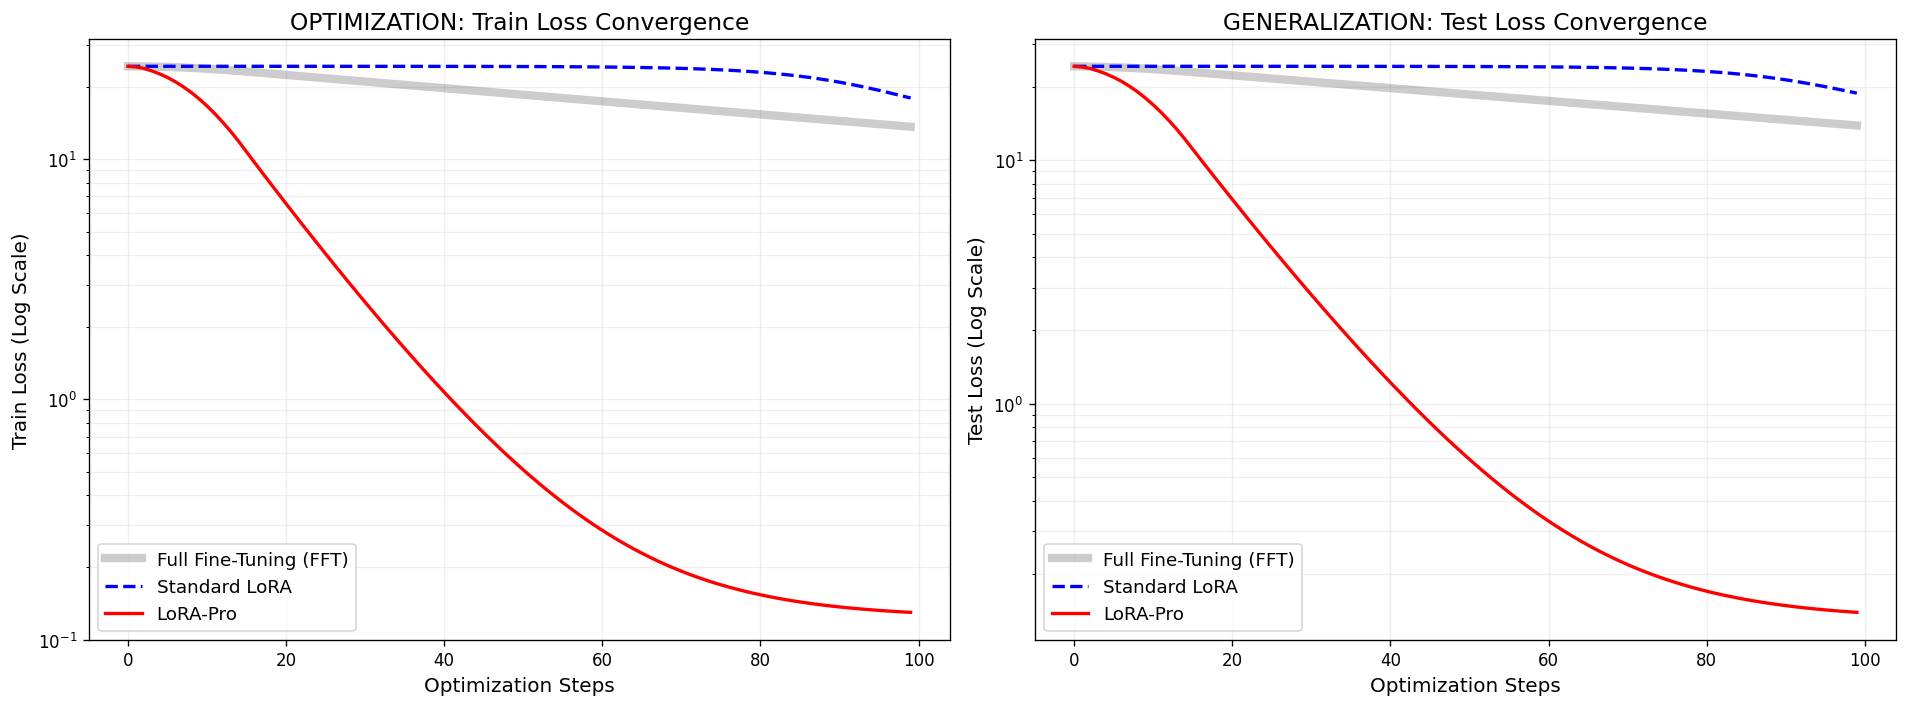

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6), dpi=120)

# --- Train Loss Subplot ---
ax1.plot(train_fft, label='Full Fine-Tuning (FFT)', lw=5, color='black', alpha=0.2)
ax1.plot(train_lora, label='Standard LoRA', ls='--', color='blue', lw=2)
ax1.plot(train_pro, label='LoRA-Pro', lw=2, color='red')
ax1.set_yscale('log')
ax1.set_xlabel('Optimization Steps', fontsize=12)
ax1.set_ylabel('Train Loss (Log Scale)', fontsize=12)
ax1.set_title('OPTIMIZATION: Train Loss Convergence', fontsize=14)
ax1.legend(fontsize=11)
ax1.grid(True, which='both', ls='-', alpha=0.2)

# --- Test Loss Subplot ---
ax2.plot(test_fft, label='Full Fine-Tuning (FFT)', lw=5, color='black', alpha=0.2)
ax2.plot(test_lora, label='Standard LoRA', ls='--', color='blue', lw=2)
ax2.plot(test_pro, label='LoRA-Pro', lw=2, color='red')
ax2.set_yscale('log')
ax2.set_xlabel('Optimization Steps', fontsize=12)
ax2.set_ylabel('Test Loss (Log Scale)', fontsize=12)
ax2.set_title('GENERALIZATION: Test Loss Convergence', fontsize=14)
ax2.legend(fontsize=11)
ax2.grid(True, which='both', ls='-', alpha=0.2)

plt.tight_layout()
plt.show()

## 7. Conclusion & Mathematical Insights
Our experiment perfectly captures the essence of the **LoRA-Pro** method (Wang et al., 2024). By closely analyzing the resulting convergence graphs, we can extract four profound insights about machine learning optimization:

### 1. The Optimization Gap is Real (Standard LoRA)
Look at the blue dashed line. Even though it starts with the exact same capacity and learning rate as the other methods, it remains completely flat for over 50 steps. Because $A$ and $B$ are initialized close to zero, standard backpropagation creates vanishingly small equivalent gradients. The optimizer wastes half of its training time stuck in this mathematical plateau before the matrices slowly grow large enough to learn.

### 2. Generalization Follows Optimization (Train vs. Test)
You will notice that the Generalization (Test) curve looks exactly like the Optimization (Train) curve. In deep neural networks, models "memorize" data, causing Train loss to drop while Test loss rises (overfitting). However, because we isolated the problem in a pure, linear toy simulation, there is no overfitting. In this environment, solving the mathematical optimization perfectly solves the generalization. While identical here, in the real-world deep learning tasks performed by the authors, closing this optimization gap was the key to achieving high test accuracy on NLP benchmarks.

### 3. The LoRA-Pro Surprise: Beating the Baseline
Notice something incredible: **LoRA-Pro (Red) isn't just matching Full Fine-Tuning (Grey)—it is destroying it!** Why does a low-rank adapter optimize *faster* than updating the full matrix? The secret lies in the mathematics of the **pseudo-inverse ($^+$)**.

Standard Full Fine-Tuning uses simple Gradient Descent (a first-order method). But by using the pseudo-inverse—which involves scaling by the inverted matrix norms—LoRA-Pro effectively acts as a **Quasi-Newton (Second-Order) optimizer**. It dynamically scales the gradient based on the curvature of the low-rank space, allowing it to take perfectly calculated leaps straight to the bottom of the loss landscape.

### 4. Pro-Tip: The Second-Order Explosion & Warmup
If you implement LoRA-Pro without a Learning Rate Warmup, you will experience a massive loss explosion on Step 1. Why? Because the equivalent update contains a mathematical "ghost term": $\eta^2 (g_B g_A)$. When $A$ and $B$ are initialized extremely small ($0.01$), their pseudo-inverses are massive ($100$). This causes the $\eta^2$ term to explode. By utilizing a **Learning Rate Warmup** (starting $\eta$ near $0$ and slowly raising it over 15 steps), we keep this term suppressed while the matrices stabilize, resulting in the beautifully smooth red curve seen above.

---
**Final Summary:** LoRA-Pro proves that by mathematically respecting the geometry of low-rank matrices, we can transform LoRA from a slow, unstable approximation into an incredibly powerful and efficient optimizer